In [1]:
# Dataset:__len__,__getitem__都可以成为Dataset

In [ ]:
dataset[0] = dataset.__getitem__[0]

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms

In [2]:
import glob

In [3]:
from PIL import Image

In [4]:
all_img_path = glob.glob(r'D:\python\PycharmProjects\pytorch_basic\dataset\image\*.jpg')

In [5]:
# 建立类别和索引之间的映射关系
species = ['cloudy', 'rain', 'shine', 'sunrise']

In [6]:
species_to_idx = dict((c, i) for i, c in enumerate(species))

In [7]:
species_to_idx

{'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}

In [8]:
# 调换一下key和value的顺序
idx_to_species = dict((v, k) for k, v in species_to_idx.items())

In [9]:
idx_to_species

{0: 'cloudy', 1: 'rain', 2: 'shine', 3: 'sunrise'}

In [10]:
'cloudy' in all_img_path[0]

True

In [11]:
# 生成所有图片的labels
all_labels = []

for img in all_img_path:
    for i, c in enumerate(species):
        if c in img:
            all_labels.append(i)

In [12]:
all_labels

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [13]:
all_img_path

['D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy1.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy10.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy100.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy101.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy102.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy103.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy104.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy105.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy106.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy107.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy108.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloudy109.jpg',
 'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\cloud

In [14]:
# 借助ndarray的索引取值的方法, 打乱数据
index = np.random.permutation(len(all_img_path))

In [15]:
all_img_path = np.array(all_img_path)[index]

In [16]:
all_labels = np.array(all_labels)[index]

In [17]:
all_img_path[:5]

array(['D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\rain74.jpg',
       'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\rain181.jpg',
       'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\shine49.jpg',
       'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\rain92.jpg',
       'D:\\python\\PycharmProjects\\pytorch_basic\\dataset\\image\\shine12.jpg'],
      dtype='<U68')

In [18]:
all_labels[:5]

array([1, 1, 2, 1, 2])

In [19]:
idx_to_species

{0: 'cloudy', 1: 'rain', 2: 'shine', 3: 'sunrise'}

In [20]:
# 手动的划分一下训练数据和测试数据
split = int(len(all_img_path) * 0.8)

In [21]:
train_imgs = all_img_path[:split]
train_labels = all_labels[:split]

test_imgs = all_img_path[split:]
test_labels = all_labels[split:]

In [22]:
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

In [121]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, img_paths, labels, transform):
        # 调用父类的init这里可以不写
        # super().__init__()
        self.imgs = img_paths
        self.labels = labels
        self.transforms = transform

    def __getitem__(self, index):
        # 根据index获取item
        img_path = self.imgs[index]
        label = self.labels[index]

        # 通过PIL的Image读取图片
        img = Image.open(img_path)
        if np.array(img).shape[-1] == 3:
            data = self.transforms(img)
            # return data, torch.from_numpy(np.array(label)).long
            return data, label
        else:
            # 否则就是有问题的图片
            print(img_path)
            return self.__getitem__(index + 1)

    def __len__(self):
        return len(self.imgs)

    # 重写collate_fn
    @staticmethod
    def collate_fn(batch):
        # batch 是个列表, 长度是batch_size,
        # 列表的每个元素是一个元组(x, y)
        # [(x1, y1), (x2, y2), (x3, y3)...]
        # collate_fn 的作用, 就是把所有的x放到一起, 所有的y放到一起
        # 把batch中None过滤掉即可
        batch = [sample for sample in batch if sample is not None]
        # 简单方法, 直接默认的collate方法
        # from torch.utils.data.dataloader import default_collate
        # return default_collate(batch)
        imgs, labels = zip(*batch)
        return torch.stack(imgs, 0), torch.as_tensor(labels)
        

In [122]:
img = Image.open(all_img_path[0])

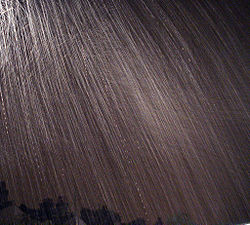

In [123]:
img

In [124]:
print(img)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x225 at 0x2331B191E00>


In [125]:
# pillow图片转化为ndarray
# np.asarray可以把一个pillow图片对象转化为ndarray
np.asarray(img).shape

(225, 250, 3)

In [126]:
dataset = MyDataset(all_img_path, all_labels, transform)

In [127]:
len(dataset)

1122

In [128]:
train_ds = MyDataset(train_imgs, train_labels, transform)
test_ds = MyDataset(test_imgs, test_labels, transform)

batch_size = 16
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=MyDataset.collate_fn, drop_last=True)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=16 * 2, collate_fn=MyDataset.collate_fn, drop_last=True)

for x, y in train_dl:
    print(x.shape, y.shape)

torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size([16, 3, 96, 96]) torch.Size([16])
torch.Size

In [95]:
imgs, labels = next(iter(train_dl))

In [96]:
imgs.shape

torch.Size([16, 3, 96, 96])

In [97]:
labels

tensor([3, 3, 0, 3, 1, 0, 0, 3, 0, 2, 0, 3, 3, 0, 2, 0])

In [98]:
import torch.nn as nn

In [129]:
# 添加BN层
# 定义模型
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3) # 16 * 94 * 94
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2) # 16 * 47 *47
        self.conv2 = nn.Conv2d(16, 32, 3) # 32 * 45 * 45 -> pooling -> 32 * 22 * 22
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3) # 64 * 20 * 20 -> pooling -> 64 * 10 * 10
        self.bn3 = nn.BatchNorm2d(64)
        self.dropout = nn.Dropout()

        # batch, channel, height, width, 64
        self.fc1 = nn.Linear(64 * 10 * 10, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.bn1(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.bn2(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.bn3(x)
        # x.view(-1, 64 * 10 * 10)
        x = nn.Flatten()(x)
        x = F.relu(self.fc1(x))
        x = self.bn_fc1(x)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.bn_fc2(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [130]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [131]:
model = Net()
# 把model拷到GPU上
if torch.cuda.is_available():
    model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [132]:
def fit(epoch, model, train_loader, test_loader):
    correct = 0
    total = 0
    running_loss = 0

    for x, y in train_loader:
        # 把数据放到GPU上去.
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            y_pred = torch.argmax(y_pred, dim=1)
            correct += (y_pred == y).sum().item()
            total += y.size(0)
            running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    # 测试过程
    test_correct = 0
    test_total = 0
    test_running_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            # 把数据放到GPU上去.
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred, y)
 
            y_pred = torch.argmax(y_pred, dim=1)
            test_correct += (y_pred == y).sum().item()
            test_total += y.size(0)
            test_running_loss += loss.item()

    test_epoch_loss = test_running_loss / len(test_loader.dataset)
    test_epoch_acc = test_correct / test_total

    print('epoch: ', epoch,
         'loss: ', round(epoch_loss, 3),
         'accuracy: ', round(epoch_acc, 3),
         'test_loss: ', round(test_epoch_loss, 3),
         'test_accuracy: ', round(test_epoch_acc, 3)
         )
    return epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc

In [133]:
epochs = 20
train_loss = []
train_acc = []
test_loss = []
test_acc = []
for epoch in range(epochs):
    epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc =  fit(epoch, model, train_dl, test_dl)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    test_loss.append(test_epoch_loss)
    test_acc.append(test_epoch_acc)

D:\python\PycharmProjects\pytorch_basic\dataset\image\shine131.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\shine127.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\cloudy71.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\cloudy66.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\rain141.jpg
epoch:  0 loss:  0.045 accuracy:  0.695 test_loss:  0.017 test_accuracy:  0.812
D:\python\PycharmProjects\pytorch_basic\dataset\image\shine127.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\shine131.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\cloudy71.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\cloudy66.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\rain141.jpg
epoch:  1 loss:  0.03 accuracy:  0.831 test_loss:  0.017 test_accuracy:  0.839
D:\python\PycharmProjects\pytorch_basic\dataset\image\shine127.jpg
D:\python\PycharmProjects\pytorch_basic\dataset\image\shine131.jpg
D:\python\PycharmProjects\pytorch_basic

In [63]:
all_labels.dtype

dtype('int64')